In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kelkalot/the-hyper-kvasir-dataset/license.txt
/kaggle/input/datasets/kelkalot/the-hyper-kvasir-dataset/labeled-images/image-labels.csv
/kaggle/input/datasets/kelkalot/the-hyper-kvasir-dataset/labeled-images/upper-gi-tract/pathological-findings/barretts/6548c39a-3f73-491e-99b9-4c364adf23ff.jpg
/kaggle/input/datasets/kelkalot/the-hyper-kvasir-dataset/labeled-images/upper-gi-tract/pathological-findings/barretts/fee3b50b-abad-4bc5-a909-cf1b291f7ef7.jpg
/kaggle/input/datasets/kelkalot/the-hyper-kvasir-dataset/labeled-images/upper-gi-tract/pathological-findings/barretts/1aab090c-fd5d-45ae-b7a5-32c5eca64840.jpg
/kaggle/input/datasets/kelkalot/the-hyper-kvasir-dataset/labeled-images/upper-gi-tract/pathological-findings/barretts/b470a84e-6560-4d7c-bb4e-2dbcbd96d17d.jpg
/kaggle/input/datasets/kelkalot/the-hyper-kvasir-dataset/labeled-images/upper-gi-tract/pathological-findings/barretts/1778d904-b13e-4461-9cd4-6a5bf1d3b37c.jpg
/kaggle/input/datasets/kelkalot/the-hyper-kvasi

In [7]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [8]:
LABELED_PATH = '/kaggle/input/datasets/kelkalot/the-hyper-kvasir-dataset/labeled-images'

NORMAL_CLASSES = [
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'anatomical-landmarks', 'pylorus'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'anatomical-landmarks', 'z-line'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'anatomical-landmarks', 'retroflex-stomach'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'anatomical-landmarks', 'cecum'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'anatomical-landmarks', 'ileum'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'anatomical-landmarks', 'retroflex-rectum'),
]

ABNORMAL_CLASSES = [
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'pathological-findings', 'barretts'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'pathological-findings', 'esophagitis-a'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'pathological-findings', 'esophagitis-b-d'),
    os.path.join(LABELED_PATH, 'upper-gi-tract', 'pathological-findings', 'barretts-short-segment'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'polyps'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'hemorrhoids'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-1'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-2'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-3'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-0-1'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-1-2'),
    os.path.join(LABELED_PATH, 'lower-gi-tract', 'pathological-findings', 'ulcerative-colitis-grade-2-3'),
]

def load_images(folder_list, label):
    paths, labels = [], []
    for folder in folder_list:
        if os.path.exists(folder):
            for f in os.listdir(folder):
                if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                    paths.append(os.path.join(folder, f))
                    labels.append(label)
        else:
            print(f"⚠️ Not found: {folder}")
    return paths, labels

normal_paths, normal_labels   = load_images(NORMAL_CLASSES, 0)
abnormal_paths, abnormal_labels = load_images(ABNORMAL_CLASSES, 1)

print(f"Normal images:   {len(normal_paths)}")
print(f"Abnormal images: {len(abnormal_paths)}")

all_paths  = normal_paths + abnormal_paths
all_labels = normal_labels + abnormal_labels

# 70% train | 15% val | 15% test  (stratified)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels, test_size=0.30, random_state=42, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print(f"\nTrain: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
print(f"Train normal: {train_labels.count(0)} | Train abnormal: {train_labels.count(1)}")

Normal images:   4104
Abnormal images: 2642

Train: 4722 | Val: 1012 | Test: 1012
Train normal: 2873 | Train abnormal: 1849


In [9]:
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class GIDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Weighted sampler to handle class imbalance
train_labels_arr = np.array(train_labels)
class_counts     = np.bincount(train_labels_arr)
class_weights    = 1.0 / class_counts
sample_weights   = class_weights[train_labels_arr]
sampler          = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dataset = GIDataset(train_paths, train_labels, train_transform)
val_dataset   = GIDataset(val_paths,   val_labels,   val_transform)
test_dataset  = GIDataset(test_paths,  test_labels,  val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler,   num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False,     num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False,     num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")
print("✅ DataLoaders ready!")

Train batches: 148
Val batches:   32
Test batches:  32
✅ DataLoaders ready!


In [10]:
class GIClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.backbone = models.resnet50(pretrained=True)

        # Freeze all layers first
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Unfreeze layer3, layer4, and fc for fine-tuning
        for param in self.backbone.layer3.parameters():
            param.requires_grad = True
        for param in self.backbone.layer4.parameters():
            param.requires_grad = True

        # Replace the final classifier
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = GIClassifier(num_classes=2, dropout=0.5).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

# Quick forward pass test
dummy = torch.randn(2, 3, 224, 224).to(device)
out   = model(dummy)
print(f"Output shape: {out.shape}")
print("✅ Model ready!")

Total params:     24,624,066
Trainable params: 23,179,138
Output shape: torch.Size([2, 2])
✅ Model ready!


In [11]:
# Class-weighted loss
total_train  = len(train_labels)
w0 = total_train / (2.0 * class_counts[0])
w1 = total_train / (2.0 * class_counts[1])
weight_tensor = torch.tensor([w0, w1], dtype=torch.float).to(device)
print(f"Class weights → Normal: {w0:.3f} | Abnormal: {w1:.3f}")

criterion = nn.CrossEntropyLoss(weight=weight_tensor)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4, weight_decay=1e-4
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-6)

# ── Training function ──────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

# ── Evaluation function ────────────────────────────────────────────────────
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            probs  = torch.softmax(outputs, dim=1)[:, 1]
            preds  = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return (total_loss / len(loader), correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

# ── Training loop ──────────────────────────────────────────────────────────
NUM_EPOCHS   = 20
best_val_acc = 0.0
history      = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("="*70)
print("TRAINING  ResNet50 Fine-tuned Classifier")
print("="*70)

for epoch in range(NUM_EPOCHS):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    v_loss, v_acc, v_preds, v_labs, v_probs = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    tag = ""
    if v_acc > best_val_acc:
        best_val_acc = v_acc
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
        tag = " ✅ saved"

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
          f"Train loss: {t_loss:.4f}  acc: {t_acc*100:.2f}%  |  "
          f"Val loss: {v_loss:.4f}  acc: {v_acc*100:.2f}%{tag}")

print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")

Class weights → Normal: 0.822 | Abnormal: 1.277
TRAINING  ResNet50 Fine-tuned Classifier


Epoch [ 1/20]  Train loss: 0.2797  acc: 87.74%  |  Val loss: 0.2025  acc: 92.69% ✅ saved


Epoch [ 2/20]  Train loss: 0.1966  acc: 91.99%  |  Val loss: 0.2020  acc: 93.28% ✅ saved


Epoch [ 3/20]  Train loss: 0.1748  acc: 93.07%  |  Val loss: 0.1903  acc: 92.79%


Epoch [ 4/20]  Train loss: 0.1507  acc: 93.75%  |  Val loss: 0.1740  acc: 93.38% ✅ saved


...

Epoch [16/20]  Train loss: 0.0350  acc: 98.84%  |  Val loss: 0.2151  acc: 95.26%


Epoch [17/20]  Train loss: 0.0307  acc: 98.90%  |  Val loss: 0.2141  acc: 95.26%


Epoch [18/20]  Train loss: 0.0304  acc: 99.05%  |  Val loss: 0.2311  acc: 94.86%


Epoch [19/20]  Train loss: 0.0234  acc: 99.22%  |  Val loss: 0.2280  acc: 94.86%


Epoch [20/20]  Train loss: 0.0246  acc: 99.17%  |  Val loss: 0.2246  acc: 95.16%

Best Val Accuracy: 95.65%


Loading best model...

       FINAL TEST SET RESULTS
  Accuracy  : 93.87%
  Precision : 91.75%
  Recall    : 92.68%
  F1-Score  : 92.21%
  ROC-AUC   : 0.9856
  TN: 583  FP: 33
  FN: 29  TP: 367

🎉 TARGET ACHIEVED — 90%+ ACCURACY!


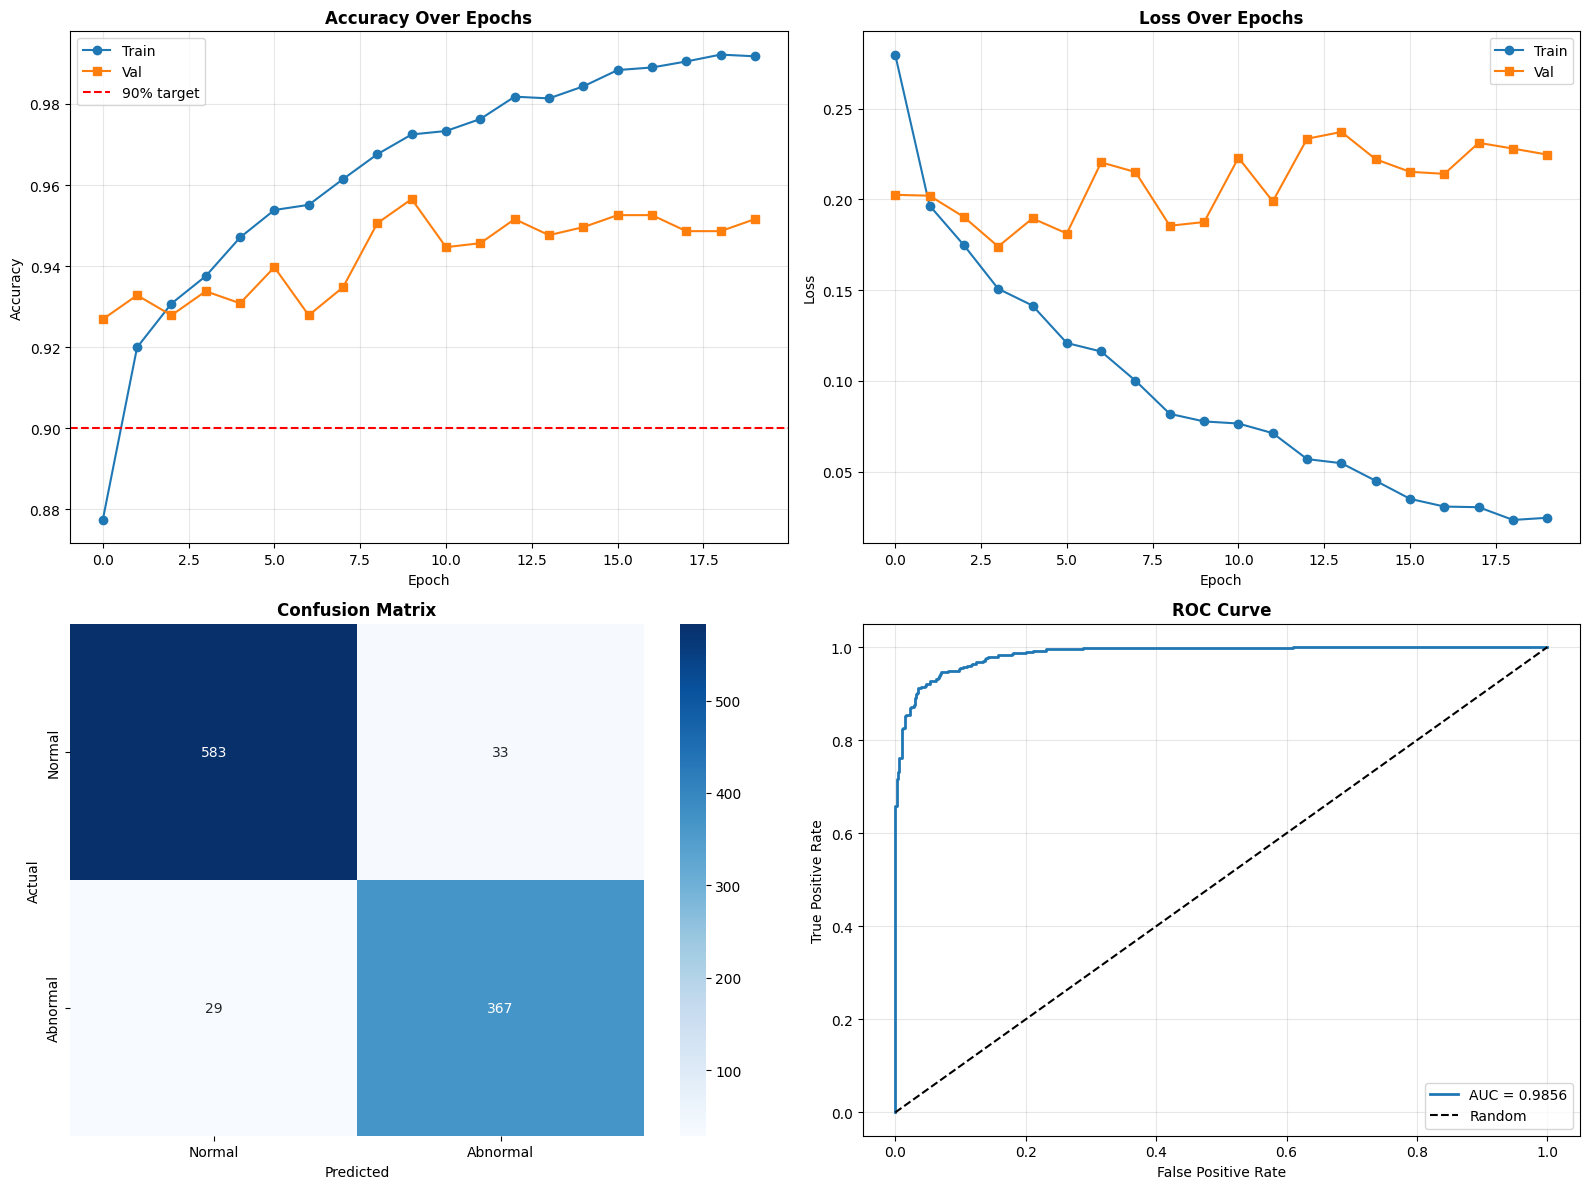

✅ Plot saved to /kaggle/working/results.png


In [12]:
print("Loading best model...")
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))

_, test_acc, test_preds, test_labs, test_probs = evaluate(model, test_loader, criterion, device)

precision = precision_score(test_labs, test_preds)
recall    = recall_score(test_labs, test_preds)
f1        = f1_score(test_labs, test_preds)
auc       = roc_auc_score(test_labs, test_probs)
cm        = confusion_matrix(test_labs, test_preds)

print("\n" + "="*60)
print("       FINAL TEST SET RESULTS")
print("="*60)
print(f"  Accuracy  : {test_acc*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print(f"  ROC-AUC   : {auc:.4f}")
print("="*60)
print(f"  TN: {cm[0,0]}  FP: {cm[0,1]}")
print(f"  FN: {cm[1,0]}  TP: {cm[1,1]}")
print("="*60)

if test_acc >= 0.90:
    print("\n🎉 TARGET ACHIEVED — 90%+ ACCURACY!")
else:
    print(f"\nGap to 90%: {(0.90 - test_acc)*100:.2f}%")

# ── Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy curves
axes[0,0].plot(history['train_acc'], marker='o', label='Train')
axes[0,0].plot(history['val_acc'],   marker='s', label='Val')
axes[0,0].axhline(0.90, color='red', linestyle='--', label='90% target')
axes[0,0].set_title('Accuracy Over Epochs', fontweight='bold')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

# 2. Loss curves
axes[0,1].plot(history['train_loss'], marker='o', label='Train')
axes[0,1].plot(history['val_loss'],   marker='s', label='Val')
axes[0,1].set_title('Loss Over Epochs', fontweight='bold')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

# 3. Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,0],
            xticklabels=['Normal','Abnormal'],
            yticklabels=['Normal','Abnormal'])
axes[1,0].set_title('Confusion Matrix', fontweight='bold')
axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('Actual')

# 4. ROC curve
fpr, tpr, _ = roc_curve(test_labs, test_probs)
axes[1,1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
axes[1,1].plot([0,1],[0,1],'k--', label='Random')
axes[1,1].set_title('ROC Curve', fontweight='bold')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Plot saved to /kaggle/working/results.png")